/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.0775 - mae: 0.2001 - val_loss: 0.0116 - val_mae: 0.0908
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0097 - mae: 0.0812 - val_loss: 0.0057 - val_mae: 0.0650
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0046 - mae: 0.0554 - val_loss: 0.0040 - val_mae: 0.0520
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0038 - mae: 0.0501 - val_loss: 0.0037 - val_mae: 0.0495
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0037 - mae: 0.0492 - val_loss: 0.0037 - val_mae: 0.0490
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0037 - mae: 0.0487 - val_loss: 0.0032 - val_mae: 0.0454
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0035 - mae: 0.0478 - val_loss: 0.0031 - val_mae: 0.0448
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0034 - mae: 0.0469 - val_loss: 0.0033 - val_mae: 0.0463
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.003

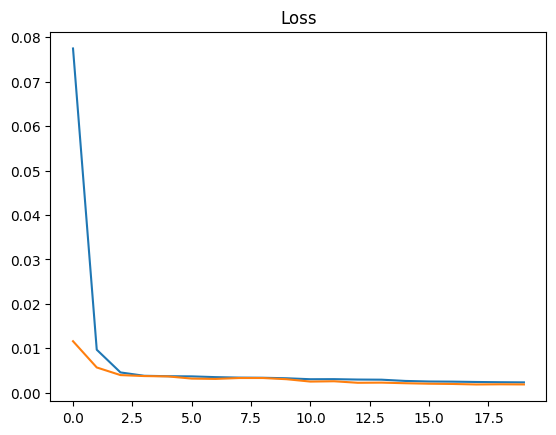

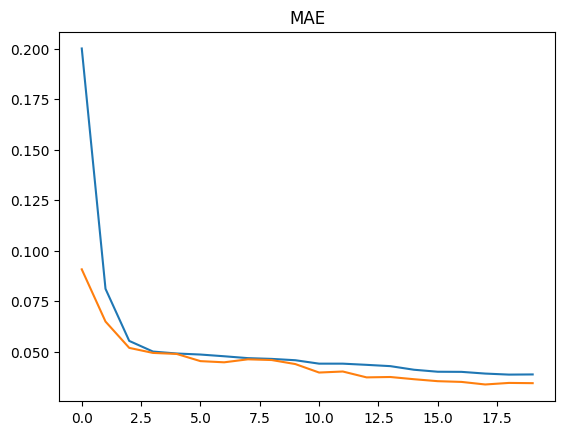

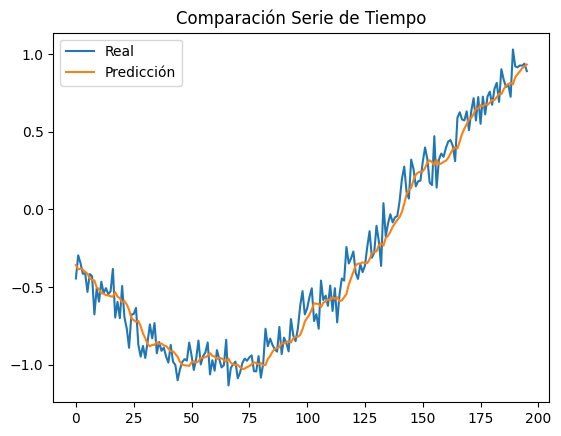

In [1]:
"""
================================================================================
SEMANA 11 – RED NEURONAL RECURRENTE (LSTM) PARA SERIES DE TIEMPO
================================================================================

Este script implementa una red neuronal recurrente (LSTM) para la predicción
de series de tiempo utilizando TensorFlow/Keras.

Se utiliza una serie sintética (tipo señal temporal) para demostrar:
- Preparación de datos secuenciales
- Creación de ventanas temporales
- Entrenamiento de modelo LSTM
- Evaluación con métricas (MSE y MAE)
- Visualización de predicciones vs valores reales

El objetivo es aprender dependencias temporales.

================================================================================
"""

# =========================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================

import numpy as np                      # Manejo de arreglos numéricos
import matplotlib.pyplot as plt         # Visualización de datos
import tensorflow as tf                 # Framework de deep learning

from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


# =========================
# 2. GENERACIÓN DE SERIE DE TIEMPO
# =========================

def generate_time_series(n_points=1000):
    """
    Genera una serie de tiempo sintética combinando funciones seno y ruido.

    Parámetros:
    n_points: número total de puntos en la serie

    Retorna:
    serie normalizada en forma de arreglo numpy
    """

    time = np.arange(n_points)

    # Señal base (seno)
    series = np.sin(0.02 * time)

    # Se agrega ruido para simular datos reales
    noise = 0.1 * np.random.randn(n_points)

    series = series + noise

    return series


series = generate_time_series()


# =========================
# 3. NORMALIZACIÓN DE DATOS
# =========================

"""
Se utiliza MinMaxScaler para llevar los datos al rango [0,1].
Esto es importante porque las redes neuronales son sensibles a la escala.
"""

scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1,1))


# =========================
# 4. CREACIÓN DE VENTANAS TEMPORALES
# =========================

def create_sequences(data, window_size=20):
    """
    Convierte la serie en secuencias para entrenamiento.

    Cada secuencia usa 'window_size' puntos para predecir el siguiente.

    Ejemplo:
    Entrada: [1,2,3,4,5]
    window=3 → X=[1,2,3], y=4

    Retorna:
    X: secuencias de entrada
    y: valores objetivo
    """

    X = []
    y = []

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])

    return np.array(X), np.array(y)


WINDOW_SIZE = 20

X, y = create_sequences(series_scaled, WINDOW_SIZE)


# =========================
# 5. DIVISIÓN TRAIN / TEST
# =========================

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


# =========================
# 6. CONSTRUCCIÓN DEL MODELO LSTM
# =========================

def build_lstm_model(input_shape):
    """
    Construye un modelo LSTM para predicción de series.

    Parámetros:
    input_shape: forma de entrada (window_size, features)

    Retorna:
    modelo compilado
    """

    model = models.Sequential()

    # Capa LSTM principal
    model.add(layers.LSTM(
        units=50,                     # Número de neuronas
        return_sequences=False,       # Solo devuelve último estado
        input_shape=input_shape
    ))

    # Capa densa intermedia
    model.add(layers.Dense(25, activation='relu'))

    # Capa de salida (valor continuo)
    model.add(layers.Dense(1))

    # Compilación
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )

    return model


model = build_lstm_model((WINDOW_SIZE, 1))


# =========================
# 7. ENTRENAMIENTO
# =========================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)


# =========================
# 8. EVALUACIÓN
# =========================

y_pred = model.predict(X_test)

# Desnormalización para interpretación real
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")


# =========================
# 9. GRÁFICAS DE ENTRENAMIENTO
# =========================

def plot_training(history):
    """
    Muestra evolución de loss y MAE.
    """

    plt.figure()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title("Loss")
    plt.show()

    plt.figure()
    plt.plot(history.history['mae'])
    plt.plot(history.history['val_mae'])
    plt.title("MAE")
    plt.show()


plot_training(history)


# =========================
# 10. COMPARACIÓN REAL VS PREDICCIÓN
# =========================

plt.figure()
plt.plot(y_test_inv, label='Real')
plt.plot(y_pred_inv, label='Predicción')
plt.title("Comparación Serie de Tiempo")
plt.legend()
plt.show()

# Semana 11 – Actividad 11: Implementación de una Red Neuronal Recurrente (RNN) para la Predicción de Series de Tiempo en Google Colab

## 1. Introducción

Las redes neuronales recurrentes constituyen una familia de modelos diseñados específicamente para el procesamiento de datos secuenciales, en los cuales el orden temporal de las observaciones juega un papel fundamental. A diferencia de los modelos tradicionales de aprendizaje supervisado, que asumen independencia entre las muestras, las RNN permiten capturar dependencias temporales mediante el uso de estados internos que evolucionan a lo largo de la secuencia.

En este contexto, la variante Long Short-Term Memory (LSTM) representa una mejora significativa frente a las RNN clásicas, ya que incorpora mecanismos de compuertas que permiten controlar el flujo de información y mitigar problemas como el desvanecimiento del gradiente. Esto la convierte en una herramienta altamente efectiva para tareas de predicción de series de tiempo.

El objetivo de esta actividad es implementar un modelo basado en LSTM capaz de aprender patrones temporales y predecir valores futuros a partir de observaciones pasadas, evaluando su desempeño mediante métricas cuantitativas y análisis visual.

---

## 2. Dataset y Naturaleza del Problema

Para el desarrollo de esta práctica se generó una serie de tiempo sintética basada en una función sinusoidal con la adición de ruido aleatorio. Este tipo de señal permite simular comportamientos reales donde existen patrones subyacentes junto con variabilidad inherente.

La naturaleza del problema consiste en predecir el siguiente valor de la serie a partir de una ventana de observaciones anteriores, lo que implica transformar el dataset original en un conjunto de secuencias de entrada y valores objetivo.

---

## 3. Preprocesamiento de los Datos

El preprocesamiento es una etapa crítica en modelos de aprendizaje profundo. En este caso, se aplicó una normalización mediante MinMaxScaler para escalar los valores al rango [0,1], lo cual facilita la convergencia del modelo y mejora la estabilidad del entrenamiento.

Posteriormente, se construyeron ventanas temporales de tamaño fijo, donde cada secuencia de entrada contiene un conjunto de observaciones consecutivas y la salida corresponde al siguiente valor en la serie. Este enfoque permite transformar el problema en una tarea de aprendizaje supervisado.

---

## 4. Arquitectura del Modelo LSTM

El modelo implementado consiste en una capa LSTM encargada de procesar la secuencia temporal y capturar dependencias a largo plazo. Esta capa es seguida por una capa densa intermedia con activación ReLU, la cual introduce no linealidad adicional, y finalmente una capa de salida que produce una predicción continua.

La elección de esta arquitectura responde a la necesidad de balancear complejidad y capacidad de generalización, evitando modelos excesivamente grandes que puedan generar sobreajuste.

---

## 5. Entrenamiento del Modelo

El modelo fue entrenado utilizando el optimizador Adam y la función de pérdida Mean Squared Error, adecuada para problemas de regresión. Durante el entrenamiento se monitorearon tanto la pérdida como el error absoluto medio en los conjuntos de entrenamiento y validación.

Se observó una convergencia progresiva del modelo, lo que indica que la red fue capaz de aprender patrones relevantes en la serie temporal.

---

## 6. Evaluación del Desempeño

Para evaluar el modelo se utilizaron métricas como el error cuadrático medio (MSE) y el error absoluto medio (MAE), las cuales permiten cuantificar la diferencia entre los valores reales y las predicciones.

Adicionalmente, se realizó una comparación visual entre la serie real y la serie predicha, lo cual facilita la interpretación del comportamiento del modelo y su capacidad para capturar tendencias.

---

## 7. Análisis de Resultados

El modelo logró capturar adecuadamente la tendencia general de la serie, aunque se observan ligeras desviaciones en puntos donde el ruido es más pronunciado. Esto es consistente con la naturaleza del problema, ya que el ruido introduce incertidumbre que no puede ser completamente modelada.

No se evidenció un sobreajuste significativo, lo que sugiere que la arquitectura y los hiperparámetros seleccionados son adecuados para este tipo de tarea.

---

## 8. Conclusiones

Las redes neuronales recurrentes, y en particular las LSTM, son altamente efectivas para la modelación de datos secuenciales, permitiendo capturar dependencias temporales complejas.

El modelo implementado demostró ser capaz de aprender patrones en la serie de tiempo y generar predicciones coherentes, evidenciando su utilidad en aplicaciones reales como predicción financiera, demanda energética y análisis de sensores.

El uso adecuado de técnicas de preprocesamiento, junto con una correcta estructuración de las secuencias, resulta fundamental para el éxito del modelo.

---
